In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,ef57e_00000,0,49.655533,bald,1,37199.634830
1,1,ef57e_00000,1,110.059769,bald,1,37199.634830
2,2,ef57e_00000,2,380.721466,bald,1,37199.634830
3,3,ef57e_00000,3,74.252228,bald,1,37199.634830
4,4,ef57e_00000,4,81.106133,bald,1,37199.634830
...,...,...,...,...,...,...,...
24995,24995,ef57e_00024,995,35.307655,random,5,40154.576485
24996,24996,ef57e_00024,996,35.342743,random,5,40154.576485
24997,24997,ef57e_00024,997,35.322502,random,5,40154.576485
24998,24998,ef57e_00024,998,35.349949,random,5,40154.576485


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
20000,20000,ef57e_00020,0,49.655533,random,1,36819.867428
20001,20001,ef57e_00020,1,49.189240,random,1,36819.867428
20002,20002,ef57e_00020,2,854.841675,random,1,36819.867428
20003,20003,ef57e_00020,3,314.133911,random,1,36819.867428
20004,20004,ef57e_00020,4,288.392914,random,1,36819.867428
...,...,...,...,...,...,...,...
24995,24995,ef57e_00024,995,35.307655,random,5,40154.576485
24996,24996,ef57e_00024,996,35.342743,random,5,40154.576485
24997,24997,ef57e_00024,997,35.322502,random,5,40154.576485
24998,24998,ef57e_00024,998,35.349949,random,5,40154.576485


In [4]:
def format_scientific_tight(value):
    """
    Formats a number using scientific notation without the + sign.
    """
    return f"{value:.1e}".replace('e+0', 'e').replace('e+', 'e')

In [5]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{format_scientific_tight(row.avg)} ± {format_scientific_tight(row.stdv)}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

/var/folders/02/fbyrwz_s7tg4vmbm1kswhxp40000gp/T/ipykernel_57027/609964943.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([int(label) + 100 for label in current_xticks])


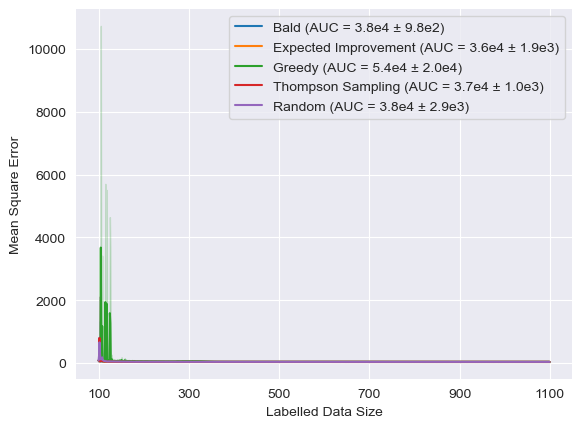

In [6]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")

current_xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([int(label) + 100 for label in current_xticks])

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
legend.set_title(None) 
    

for spine in ax.spines.values():
    spine.set_visible(False)